In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/amria/machine-l/Sport car price.csv")
df.head()

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"


In [20]:
# (Task 1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


In [7]:
df.describe()

,Year
count,1007.000000
mean,2021.201589
std,2.019802
min,1965.000000
25%,2021.000000
50%,2021.000000
75%,2022.000000
max,2023.000000


In [8]:
df.isnull().sum()

Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            10
Horsepower                  0
Torque (lb-ft)              3
0-60 MPH Time (seconds)     0
Price (in USD)              0
dtype: int64

In [12]:
df['Price (in USD)'] = df['Price (in USD)'].astype(str)
df['Price (in USD)'] = df['Price (in USD)'].str.replace(',', '')
df['Price (in USD)'] = df['Price (in USD)'].astype(float)

In [14]:
df['Engine Size (L)'] = pd.to_numeric(df['Engine Size (L)'], errors='coerce')
df['Horsepower'] = pd.to_numeric(df['Horsepower'], errors='coerce')
df['Torque (lb-ft)'] = pd.to_numeric(df['Torque (lb-ft)'], errors='coerce')
df['0-60 MPH Time (seconds)'] = pd.to_numeric(df['0-60 MPH Time (seconds)'], errors='coerce')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car Make                 1007 non-null   object 
 1   Car Model                1007 non-null   object 
 2   Year                     1007 non-null   int64  
 3   Engine Size (L)          948 non-null    float64
 4   Horsepower               998 non-null    float64
 5   Torque (lb-ft)           999 non-null    float64
 6   0-60 MPH Time (seconds)  1006 non-null   float64
 7   Price (in USD)           1007 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 63.1+ KB


The dataset was loaded and explored using pandas. Initial inspection showed that some columns had missing values and some numeric columns were stored as text. Data cleaning is required before further analysis Some numeric columns were stored as strings and the price column contained commas. These columns were converted to numeric format using pandas.



In [21]:
# Missing Values (Task 2)  We use median because it is better with extreme values

In [17]:
df['Engine Size (L)'] = df['Engine Size (L)'].fillna(df['Engine Size (L)'].median())

df['Torque (lb-ft)'] = df['Torque (lb-ft)'].fillna(df['Torque (lb-ft)'].median())

In [18]:
df.isnull().sum()

Car Make                   0
Car Model                  0
Year                       0
Engine Size (L)            0
Horsepower                 9
Torque (lb-ft)             0
0-60 MPH Time (seconds)    1
Price (in USD)             0
dtype: int64

Missing values were handled using median imputation. The median is preferred because it is less sensitive to extreme values compared to the mean.


In [45]:
# Outliers (Task 3)

In [23]:
Q1 = df['Price (in USD)'].quantile(0.25)
Q3 = df['Price (in USD)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price (in USD)'] < lower) | (df['Price (in USD)'] > upper)]

outliers

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
11,Bugatti,Chiron,2021,8.0,1500.0,1180.0,2.40,3000000.0
14,Koenigsegg,Jesko,2021,5.0,1280.0,1015.0,2.50,2800000.0
24,Pagani,Huayra,2021,6.0,720.0,737.0,2.80,2800000.0
26,Rimac,Nevera,2022,4.0,1914.0,1696.0,1.85,2400000.0
28,Lamborghini,Aventador SVJ,2021,6.5,759.0,531.0,2.80,517770.0
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5.0,1280.0,1106.0,2.50,3000000.0
1003,Lotus,Evija,2021,4.0,1972.0,1254.0,2.00,2000000.0
1004,McLaren,Senna,2021,4.0,789.0,590.0,2.70,1000000.0
1005,Pagani,Huayra,2021,6.0,764.0,738.0,3.00,2600000.0


In [24]:
df = df[(df['Price (in USD)'] >= lower) & (df['Price (in USD)'] <= upper)]

Outliers were detected using the Interquartile Range (IQR) method. Values outside the acceptable range were removed from the dataset.

In [25]:
# Normalization (Task 4)

In [26]:
# MinMax
df['Price_MinMax'] = (df['Price (in USD)'] - df['Price (in USD)'].min()) / (df['Price (in USD)'].max() - df['Price (in USD)'].min())

In [27]:
# Z-Score
df['Price_Zscore'] = (df['Price (in USD)'] - df['Price (in USD)'].mean()) / df['Price (in USD)'].std()

Two normalization techniques were applied: Min-Max normalization and Z-score normalization to scale the numerical data.

In [38]:
# PCA (Task 5) 

features = features.fillna(features.median())

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

pca = PCA()

pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

print(explained_variance)


[0.52924839 0.19250883 0.13766799 0.08682671 0.04288257 0.01086551]


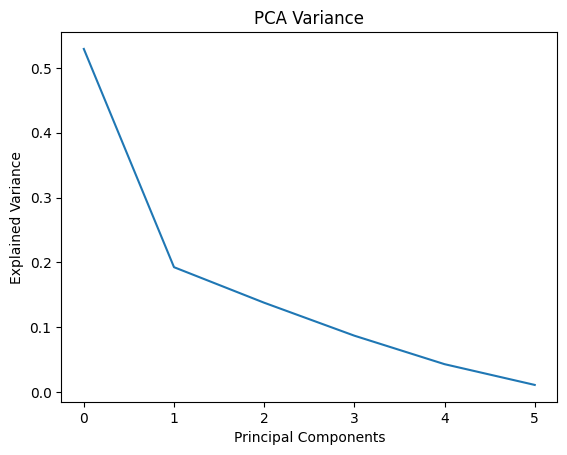

In [40]:
plt.plot(explained_variance)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("PCA Variance")
plt.show()

Principal Component Analysis (PCA) was applied after standardizing the dataset. The explained variance ratio shows how much variance each principal component captures. The first few components explain most of the variance in the dataset.

this assignment, the dataset was cleaned by converting columns to numeric format and handling missing values. Outliers were detected using the IQR method. Data normalization techniques were applied, and PCA was used to reduce dimensionality and analyze the variance explained by different components.